In [1]:
import torch
from nnsight import LanguageModel

In [2]:
model_name = "meta-llama/Llama-3.2-1B-Instruct"

model = LanguageModel(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

In [3]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb):

In [5]:
model.device

device(type='meta')

In [4]:
PROMPT_TEMPLATE = "Q: Which of the following entities has a profession in common with {}? {}.\nA:"

subj = "Albert Einstein"

entity_list = ["Brad Pitt", "Isaac Newton", "Michael Jackson"]

prompt = PROMPT_TEMPLATE.format(subj, (", ").join(entity_list))
print("Prompt:", prompt, "\n")

Prompt: Q: Which of the following entities has a profession in common with Albert Einstein? Brad Pitt, Isaac Newton, Michael Jackson.
A: 



In [5]:
with model.generate(prompt, max_new_tokens=10) as tracer:
    output = model.generator.output.save()

output

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


tensor([[128000,     48,     25,  16299,    315,    279,   2768,  15086,    706,
            264,   4913,    304,   4279,    449,  17971,  55152,     30,  17478,
          21823,     11,  42608,  21324,     11,   8096,  13972,    627,     32,
             25,   2290,    315,    279,   3485,     13,  17971,  55152,    574,
            264,  83323]], device='mps:0')

In [6]:
freeform_subj = "The person of interest in question here at this time is that person who is known by the name Isaac Newton"

In [7]:
prompt_input_ids = model.tokenizer.encode(prompt)
print(prompt_input_ids[20:])

freeform_input_ids = model.tokenizer.encode(freeform_subj)
#model.tokenizer.decode()
print(freeform_input_ids[20:])

[42608, 21324, 11, 8096, 13972, 627, 32, 25]
[42608, 21324]


In [8]:
target_entity_range = [20, 21]

In [9]:
target_token_id = model.tokenizer.encode(" Isaac", add_special_tokens=False)

In [11]:
type(model.tokenizer)

transformers.tokenization_utils_fast.PreTrainedTokenizerFast

In [15]:
%load_ext autoreload
%autoreload 2

In [17]:
from source.analysis import collect_activations

resid_activations = collect_activations(
    model=model,
    prompt=prompt,
    kind="residual"
)

len(resid_activations)

  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:01<00:00, 12.15it/s]


16

In [14]:
from tqdm import trange

clean_activations = []
for l in trange(model.config.num_hidden_layers):
    with model.trace(prompt):
        residual_output = model.model.layers[l].output[0].save()
        clean_activations.append(residual_output)
        clean_target_logits = model.output.logits[0][-1, target_token_id].item().save()

print(f"{clean_target_logits=}")
print(f"{len(clean_activations)=}")

100%|██████████| 16/16 [00:01<00:00, 13.52it/s]

clean_target_logits=18.390625
len(clean_activations)=16


In [74]:
freeform_activations = []
with model.trace(freeform_subj):
    for l in range(model.config.num_hidden_layers):
        residual_output = model.model.layers[l].output[0].save()
        freeform_activations.append(residual_output)

print(f"{len(freeform_activations)}")

80


In [27]:
from source.analysis import activation_patch

patched_activations = activation_patch(
    model=model,
    prompt=prompt,
    activations=clean_activations,
    target_token_id=target_token_id,
    target_logits=clean_target_logits,
    kind="residual",
    patch_range=target_entity_range,
    log=True
)

All Layers:   0%|          | 0/16 [00:00<?, ?it/s]

All Layers: 100%|██████████| 16/16 [00:28<00:00,  1.78s/it]


In [ ]:
from tqdm import trange

patched_activations = []

# Loop through the model layers
for l in trange(model.config.num_hidden_layers):
    patch_at_layer = []

    # For each token position
    for t in range(len(prompt_input_ids)):

        # Run the model on the prompt
        with model.trace(prompt):

            # If we're at the target entity tokens
            if t in target_entity_range:

                # Replace the residual stream
                model.model.layers[l].output[0][:, t, :] = freeform_activations[l][:, t, :]

            # Get the model output logits
            patched_logits = model.output.logits[0].save()

            # Get the logits for the target
            patched_target_logits = patched_logits[-1, target_token_id].item().save()

            # Calculate the logit difference
            logit_diff = patched_target_logits - clean_target_logits

            # Save the logit_diff
            logit_diff = logit_diff.save()

        # Print the layer, token, and logit difference
        print(f"L{l}, T{t}, LD={logit_diff}")

        # Append the token to our list of logit differences at the current layer
        patch_at_layer.append(logit_diff)
    
    # Append each layer's logit differences list to our overall list of lists
    patched_activations.append(patch_at_layer)

print(f"\\nPatched activations shape: {len(patched_activations)} layers x {len(patched_activations[0])} tokens")

                

Scores shape after transpose: (28, 16)
Data range: min=0.0000, max=0.0000


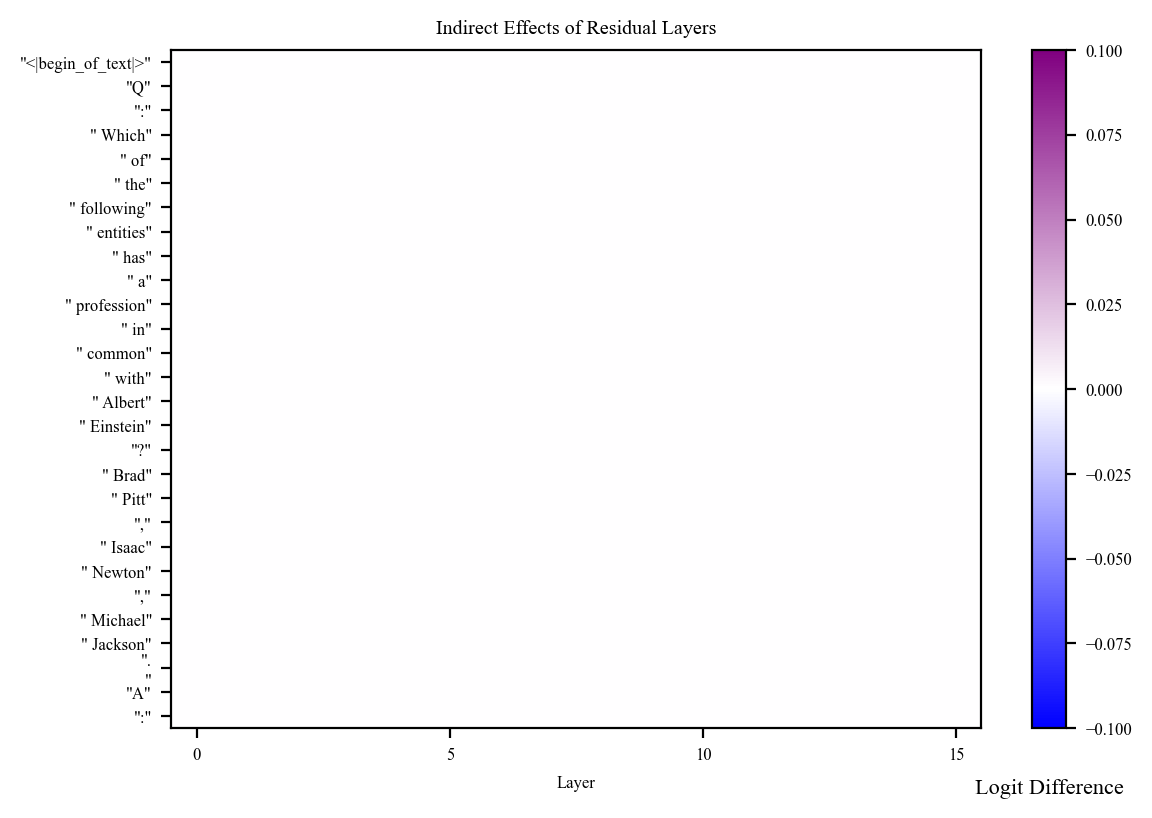

Data shape: (28, 16)
Number of tokens: 28


In [28]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Create a 2D array: layers as rows, tokens as columns, then transpose
scores = np.array(patched_activations).T  # Transpose so tokens are rows, layers are columns
print(f"Scores shape after transpose: {scores.shape}")

# Decode tokens to actual text
prompt_tokens = [model.tokenizer.decode([token_id]) for token_id in prompt_input_ids]

# Create token labels
tokens = []
for idx, tok in enumerate(prompt_tokens):
    tokens.append(f'"{tok}"')

# We will truncate to the 0 to 1 range, but this is the full actual range.
print(f"Data range: min={scores.min():.4f}, max={scores.max():.4f}")

plt.rcdefaults()
with plt.rc_context(
    rc={
        "font.family": "Times New Roman",
        "font.size": 6,
    }
):
    # Set figure size
    fig, ax = plt.subplots(
        figsize=(
            6,
            len(tokens) * 0.08 + 1.8
        ),
        dpi=200
    )
    
    M = np.max(np.abs(scores))

    # Scale range
    scale_kwargs = {
        "vmin": -M,
        "vmax": +M
    }

    cmap = LinearSegmentedColormap.from_list(
        "BlueWhitePurple",
        ['blue', 'white', 'purple']
    )

    heatmap = ax.pcolor(
        scores,
        cmap=cmap,
        **scale_kwargs,
    )

    ax.invert_yaxis()
    
    # Y-axis: token labels (rows)
    ax.set_yticks([0.5 + i for i in range(scores.shape[0])])  # Number of tokens
    ax.set_yticklabels(tokens)
    
    # X-axis: layer labels (columns)
    num_layers = scores.shape[1]
    tick_indices = np.arange(0, num_layers, 5)
    ax.set_xticks(tick_indices + 0.5)  # Number of layers
    ax.set_xticklabels(tick_indices)

    title = f"Indirect Effects of Residual Layers"
    ax.set_title(title)

    ax.set_xlabel("Layer")
    #ax.set_ylabel("Tokens")

    color_scale = plt.colorbar(heatmap)
    color_scale.ax.set_title(
        f"Logit Difference",
        y=-0.12,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

print(f"Data shape: {scores.shape}")
print(f"Number of tokens: {len(tokens)}")



In [77]:
clean_mlp_activations = []
with model.trace(prompt):
    for l in range(model.config.num_hidden_layers):
        mlp_output = model.model.layers[l].mlp.output[0].save()
        clean_mlp_activations.append(mlp_output)
    clean_target_logits = model.output.logits[0][-1, target_token_id].item().save()

print(f"{clean_target_logits=}")
print(f"{len(clean_mlp_activations)=}")

clean_target_logits=20.0625
len(clean_mlp_activations)=80


In [78]:
freeform_mlp_activations = []
with model.trace(freeform_subj):
    for l in range(model.config.num_hidden_layers):
        mlp_output = model.model.layers[l].mlp.output[0].save()
        freeform_mlp_activations.append(mlp_output)

print(f"{len(freeform_mlp_activations)}")

80


In [ ]:
from tqdm import trange

window_size = 5
num_layers = model.config.num_hidden_layers

windowed_mlp_results = []
for window_start_l in trange(num_layers - window_size + 1):
    patch_at_token = []
    for t in range(len(prompt_input_ids)):

        # Single forward pass for the entire window
        with model.trace(prompt):

            if t in target_entity_range:

                # Apply the patch for all layers within this window
                for l_offset in range(window_size):
                    l_in_window = window_start_l + l_offset

                    model.model.layers[l_in_window].mlp.output[0][t] = freeform_mlp_activations[l_in_window][t]

            # Get the final logits after all 5 patches are in place
            patched_logits = model.output.logits[0].save()

            # Get the logits for the clean target
            patched_target_logits = patched_logits[-1, target_token_id].item().save()

            # Calculate the logit difference
            logit_diff = patched_target_logits - clean_target_logits

            logit_diff = logit_diff.save()

        # Print the layer, token, and logit difference
        print(f"L{window_start_l}, T{t}, LD={logit_diff}")

        # Append the token to our list of logit differences at the current layer
        patch_at_token.append(logit_diff)
    
    # Append each layer's logit differences list to our overall list of lists
    windowed_mlp_results.append(patch_at_token)


#print(f"\\nPatched activations shape: {len(patched_activations)} layers x {len(patched_activations[0])} tokens")

Scores shape after transpose: (28, 76)
Data range: min=-0.2344, max=0.0938


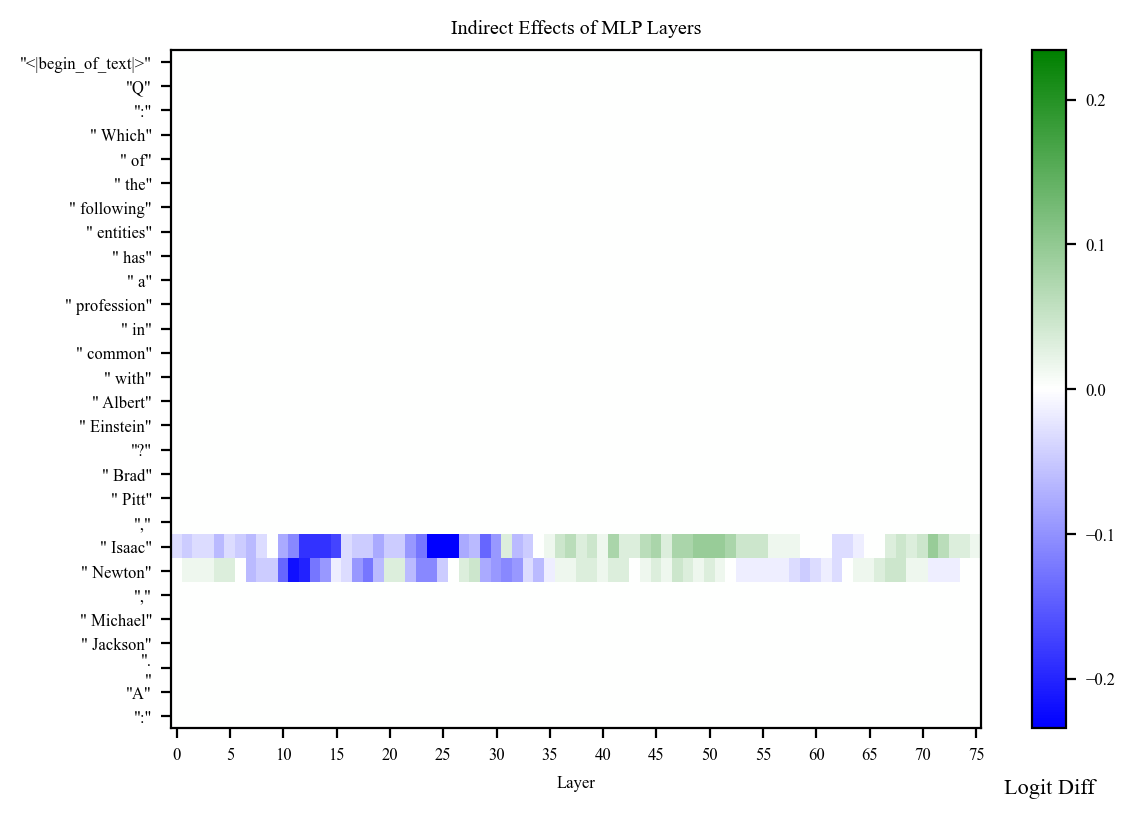

Data shape: (28, 76)
Number of tokens: 28


In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2D array: layers as rows, tokens as columns, then transpose
scores = np.array(windowed_mlp_results).T  # Transpose so tokens are rows, layers are columns
#scores = np.array(patched_activations).T  # Transpose so tokens are rows, layers are columns
print(f"Scores shape after transpose: {scores.shape}")

# Decode tokens to actual text
prompt_tokens = [model.tokenizer.decode([token_id]) for token_id in prompt_input_ids]

# Create token labels
tokens = []
for idx, tok in enumerate(prompt_tokens):
    tokens.append(f'"{tok}"')

# We will truncate to the 0 to 1 range, but this is the full actual range.
print(f"Data range: min={scores.min():.4f}, max={scores.max():.4f}")
#scores = np.clip(scores, 0, 1)

plt.rcdefaults()
with plt.rc_context(
    rc={
        "font.family": "Times New Roman",
        "font.size": 6,
    }
):
    # Set figure size
    fig, ax = plt.subplots(
        figsize=(
            6,
            len(tokens) * 0.08 + 1.8
        ),
        dpi=200
    )
    
    M = np.max(np.abs(scores))

    # Scale range
    scale_kwargs = {
        "vmin": -M,
        "vmax": +M
    }

    cmap = LinearSegmentedColormap.from_list(
        "BlueWhiteGreen",
        ['blue', 'white', 'green']
    )

    heatmap = ax.pcolor(
        scores,
        cmap=cmap,
        **scale_kwargs,
    )

    ax.invert_yaxis()
    
    # Y-axis: token labels (rows)
    ax.set_yticks([0.5 + i for i in range(scores.shape[0])])  # Number of tokens
    ax.set_yticklabels(tokens)
    
    # X-axis: layer labels (columns)
    num_layers = scores.shape[1]
    tick_indices = np.arange(0, num_layers, 5)
    ax.set_xticks(tick_indices + 0.5)  # Number of layers
    ax.set_xticklabels(tick_indices)

    title = f"Indirect Effects of MLP Layers"
    ax.set_title(title)

    ax.set_xlabel("Layer")
    #ax.set_ylabel("Tokens")

    color_scale = plt.colorbar(heatmap)
    color_scale.ax.set_title(
        f"Logit Diff",
        y=-0.12,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

print(f"Data shape: {scores.shape}")
print(f"Number of tokens: {len(tokens)}")



In [81]:
clean_activations = []
with model.trace(prompt):
    for l in range(model.config.num_hidden_layers):
        residual_output = model.model.layers[l].output[0].save()
        clean_activations.append(residual_output)
    clean_target_logits = model.output.logits[0][-1, target_token_id].item().save()

print(f"{clean_target_logits=}")
print(f"{len(clean_activations)=}")

clean_target_logits=20.0625
len(clean_activations)=80


In [82]:
freeform_activations = []
with model.trace(freeform_subj):
    for l in range(model.config.num_hidden_layers):
        residual_output = model.model.layers[l].output[0].save()
        freeform_activations.append(residual_output)

print(f"{len(freeform_activations)}")

80


In [83]:
clean_attn_activations = []
with model.trace(prompt):
    for l in range(model.config.num_hidden_layers):
        # The input to the output projection combines all head outputs
        attn_outputs = model.model.layers[l].self_attn.output[0].save()
        clean_attn_activations.append(attn_outputs)
    clean_target_logits = model.output.logits[0][-1, target_token_id].item().save()
print(f"{clean_target_logits=}")
print(f"{len(clean_attn_activations)=}") 


clean_target_logits=20.0625
len(clean_attn_activations)=80


In [84]:
freeform_attn_activations = []
with model.trace(freeform_subj):
    for l in range(model.config.num_hidden_layers):
        attn_output = model.model.layers[l].self_attn.output[0].save()
        freeform_attn_activations.append(attn_output)

print(f"{len(freeform_attn_activations)}")

80


In [ ]:
from tqdm import trange

window_size = 5
num_layers = model.config.num_hidden_layers

windowed_attn_results = []

for window_start_l in trange(num_layers - window_size + 1):

    results_for_window = []
    for t in range(len(prompt_input_ids)):

        # Single forward pass for entire window/token patch
        with model.trace(prompt):

            #attn_out = model.model.layers[l_in_window].self_attn.output[0][0].save()

            if t in target_entity_range:

                # Apply the patch for all layers within this window
                for l_offset in range(window_size):
                    l_in_window = window_start_l + l_offset

                model.model.layers[l_in_window].self_attn.output[0][0][t] = freeform_attn_activations[l_in_window][0][t]

            patched_target_logits = model.output.logits[0, -1, target_token_id].save()

            # Normalize and score
            logit_diff = patched_target_logits - clean_target_logits

            logit_diff = logit_diff.item().save()

        # Print the layer, token, and logit difference
        print(f"L{window_start_l}, T{t}, LD={logit_diff}")
        #print(f"{attn_out[0].shape=}")

        # Append the token to our list of logit differences at the current layer
        results_for_window.append(logit_diff)
    
    # Append each layer's logit differences list to our overall list of lists
    windowed_attn_results.append(results_for_window)


Scores shape after transpose: (28, 76)
Data range: min=-0.1406, max=0.0469


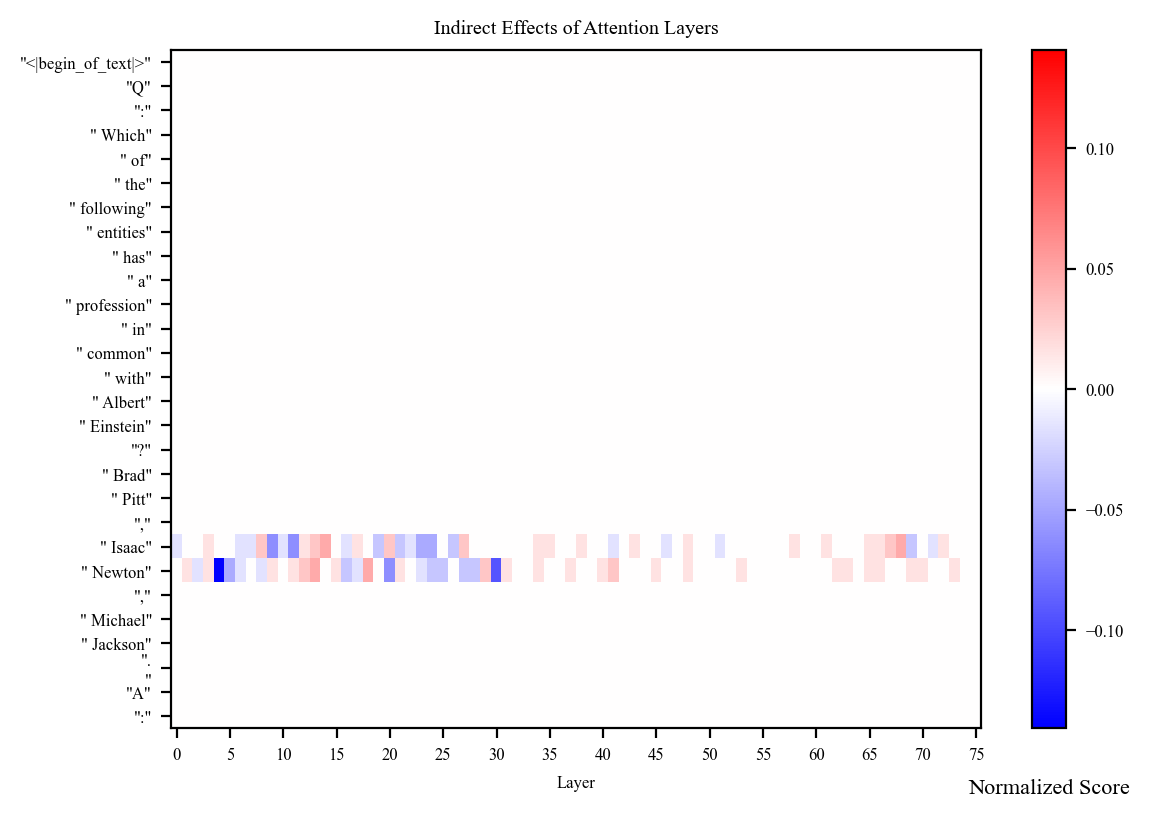

Data shape: (28, 76)
Number of tokens: 28


In [103]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2D array: layers as rows, tokens as columns, then transpose
scores = np.array(windowed_attn_results).T  # Transpose so tokens are rows, layers are columns
#scores = np.array(patched_activations).T  # Transpose so tokens are rows, layers are columns
print(f"Scores shape after transpose: {scores.shape}")

# Decode tokens to actual text
prompt_tokens = [model.tokenizer.decode([token_id]) for token_id in prompt_input_ids]

# Create token labels
tokens = []
for idx, tok in enumerate(prompt_tokens):
    tokens.append(f'"{tok}"')

# We will truncate to the 0 to 1 range, but this is the full actual range.
print(f"Data range: min={scores.min():.4f}, max={scores.max():.4f}")
#scores = np.clip(scores, 0, 1)

plt.rcdefaults()
with plt.rc_context(
    rc={
        "font.family": "Times New Roman",
        "font.size": 6,
    }
):
    # Set figure size
    fig, ax = plt.subplots(
        figsize=(
            6,
            len(tokens) * 0.08 + 1.8
        ),
        dpi=200
    )
    
    M = np.max(np.abs(scores))

    # Scale range
    scale_kwargs = {
        "vmin": -M,
        "vmax": +M
    }

    cmap = LinearSegmentedColormap.from_list(
        "BlueWhiteRed",
        ['blue', 'white', 'red']
    )

    heatmap = ax.pcolor(
        scores,
        cmap=cmap,
        **scale_kwargs,
    )

    ax.invert_yaxis()
    
    # Y-axis: token labels (rows)
    ax.set_yticks([0.5 + i for i in range(scores.shape[0])])  # Number of tokens
    ax.set_yticklabels(tokens)
    
    # X-axis: layer labels (columns)
    num_layers = scores.shape[1]
    tick_indices = np.arange(0, num_layers, 5)
    ax.set_xticks(tick_indices + 0.5)  # Number of layers
    ax.set_xticklabels(tick_indices)

    title = f"Indirect Effects of Attention Layers"
    ax.set_title(title)

    ax.set_xlabel("Layer")
    #ax.set_ylabel("Tokens")

    color_scale = plt.colorbar(heatmap)
    color_scale.ax.set_title(
        f"Normalized Score",
        y=-0.12,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

print(f"Data shape: {scores.shape}")
print(f"Number of tokens: {len(tokens)}")

